# Lab 8: Heuristic Search Algorithms

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq
from collections import deque
import numpy as np

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['figure.dpi'] = 100

## Part 1: Building a Weighted Graph with Heuristic Values

### 1.1 The Ireland Map

In Lab 7, our maze had unweighted edges — every step cost the same. In the real world, edges have different costs (e.g., distances between cities). Heuristic search algorithms exploit additional knowledge about the problem — specifically, an estimate of how far each node is from the goal — to search more efficiently.

We'll use a map of Ireland as our search problem. The goal is to find the best route from Galway to Waterford.

Each city (node) has:

- Edges with actual distances (in km) to neighbouring cities.
- A heuristic value h(n): the estimated straight-line ("crow-flies") distance to Waterford.


### 1.2 Building the Graph

In [2]:
# Build the Ireland map as a weighted graph
ireland = nx.Graph()

# Add edges with distances (km)
ireland.add_edge('Galway', 'Limerick', weight=105)
ireland.add_edge('Galway', 'Belfast', weight=306)
# TODO: add the remaining edges & distances (see this cell's output)
ireland.add_edge('Limerick', 'Belfast', weight=323)
ireland.add_edge('Limerick', 'Cork', weight=121)
ireland.add_edge('Belfast', 'Dublin', weight=167)
ireland.add_edge('Cork', 'Dublin', weight=220)
ireland.add_edge('Cork', 'Waterford', weight=126)
ireland.add_edge('Dublin', 'Waterford', weight=158)

# Heuristic: straight-line distance to Waterford (km)
heuristic = {
    'Galway': 200, 'Limerick': 170, 'Belfast': 270,
    'Cork': 120, 'Dublin': 130, 'Waterford': 0
}

# Store heuristic as node attribute
for city, h in heuristic.items():
    ireland.nodes[city]['h'] = h

print("Cities:", list(ireland.nodes()))
print("\nConnections and distances:")
for u, v, data in ireland.edges(data=True):
    print(f" {u} <-> {v}: {data['weight']} km")
print("\nHeuristic values (crow-flies distance to Waterford):")

for city, h in sorted(heuristic.items(), key=lambda x: x[1]):
    print(f" {city}: h = {h} km")

Cities: ['Galway', 'Limerick', 'Belfast', 'Cork', 'Dublin', 'Waterford']

Connections and distances:
 Galway <-> Limerick: 105 km
 Galway <-> Belfast: 306 km
 Limerick <-> Belfast: 323 km
 Limerick <-> Cork: 121 km
 Belfast <-> Dublin: 167 km
 Cork <-> Dublin: 220 km
 Cork <-> Waterford: 126 km
 Dublin <-> Waterford: 158 km

Heuristic values (crow-flies distance to Waterford):
 Waterford: h = 0 km
 Cork: h = 120 km
 Dublin: h = 130 km
 Limerick: h = 170 km
 Galway: h = 200 km
 Belfast: h = 270 km


### 1.3 Visualising the Ireland Map


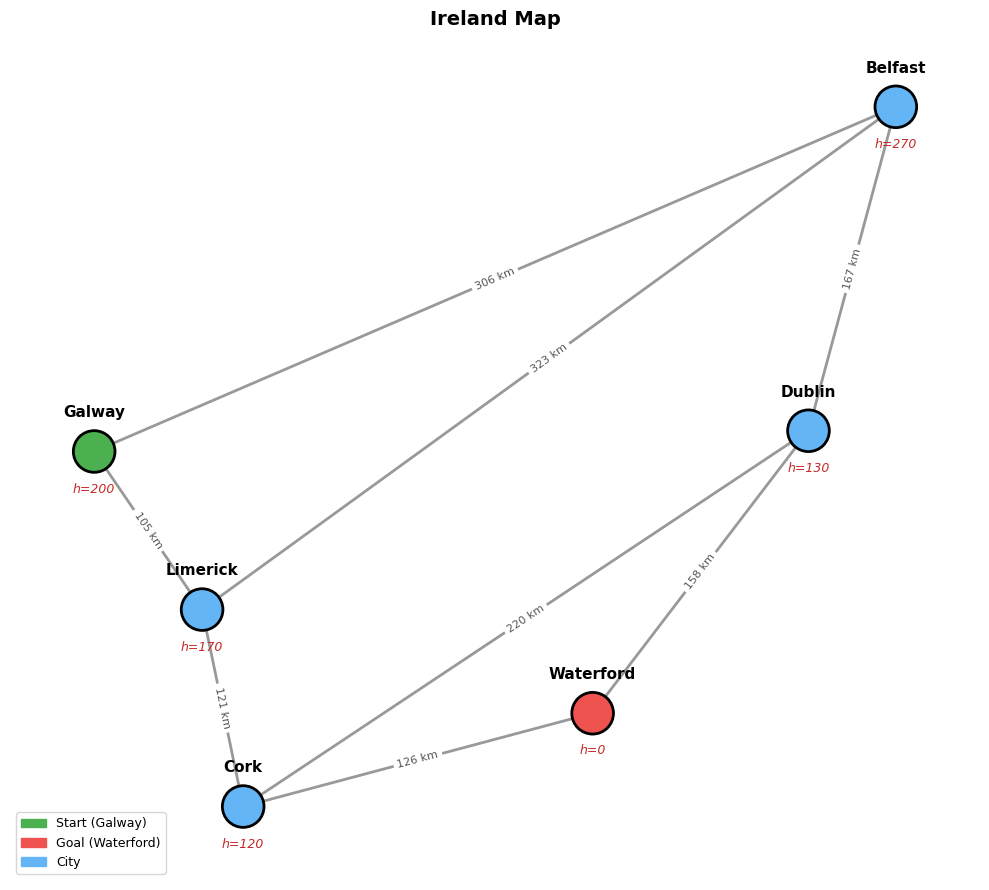

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Geographic-ish positions for Irish cities
ireland_pos = {
    'Galway': (-9.05, 53.27),
    'Limerick': (-8.63, 52.66),
    'Cork': (-8.47, 51.90),
    'Waterford': (-7.11, 52.26),
    'Dublin': (-6.27, 53.35),
    'Belfast': (-5.93, 54.60),
}

def draw_ireland(graph, pos, h, title='Ireland Map', highlight_path=None,
                 highlight_cost=None, extra_nodes=None, extra_h=None):
    """Draw the Ireland map with distances and heuristic values."""
    fig, ax = plt.subplots(figsize=(10, 9))

    all_h = dict(h)
    if extra_h:
        all_h.update(extra_h)

    # Node colours
    node_colors = []
    for n in graph.nodes():
        if n == 'Galway':
            node_colors.append('#4CAF50')      # start
        elif n == 'Waterford':
            node_colors.append('#EF5350')      # goal
        else:
            node_colors.append('#64B5F6')      # regular

    # Draw edges with distance labels
    nx.draw_networkx_edges(graph, pos, ax=ax, edge_color='#999999', width=2)
    edge_labels = {(u, v): f"{d['weight']} km" for u, v, d in graph.edges(data=True)}
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, ax=ax,
                                 font_size=8, font_color='#555555')

    # Highlight path if provided
    if highlight_path:
        path_edges = list(zip(highlight_path[:-1], highlight_path[1:]))
        nx.draw_networkx_edges(graph, pos, edgelist=path_edges,
                               edge_color='#E91E63', width=2, ax=ax)

    # Draw nodes
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_color=node_colors,
                           node_size=900, edgecolors='black', linewidths=2)

    # Labels: city name and h(n) value
    for node, (x, y) in pos.items():
        ax.text(x, y + 0.12, node, ha='center', va='bottom',
                fontsize=11, fontweight='bold')
        if node in all_h:
            ax.text(x, y - 0.12, f'h={all_h[node]}', ha='center', va='top',
                    fontsize=9, color='#C62828', fontstyle='italic')

    # Legend
    legend_items = [
        mpatches.Patch(color='#4CAF50', label='Start (Galway)'),
        mpatches.Patch(color='#EF5350', label='Goal (Waterford)'),
        mpatches.Patch(color='#64B5F6', label='City'),
    ]
    if highlight_path:
        cost_str = f' (cost: {highlight_cost} km)' if highlight_cost else ''
        legend_items.append(mpatches.Patch(color='#E91E63',
                           label=f'Path: {" → ".join(highlight_path)}{cost_str}'))
    ax.legend(handles=legend_items, loc='lower left', fontsize=9)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Draw the map
draw_ireland(ireland, ireland_pos, heuristic)

### 1.4 Admissibility and Consistency

In [4]:
# Check admissibility: h(n) <= actual shortest distance to Waterford
print("Admissibility Check")
print("=" * 60)
# TODO: Use the appropriate NetworkX function to compute into "shortest_to_goal" the shortest
# path lengths from Waterford to all other reachable cities using Dijkstra's algorithm.
shortest_to_goal = nx.single_source_dijkstra_path_length(ireland, 'Waterford')

for city in sorted(ireland.nodes()):
    actual = shortest_to_goal[city]
    h = heuristic[city]
    admissible = h <= actual
    print(f" {city:>10}: h={h:>3}, actual shortest={actual:>3}, "
        f"h <= actual? {admissible} {'✓' if admissible else '✗ NOT ADMISSIBLE'}")
    
# Check consistency: h(n) <= c(n,n') + h(n') for all edges
print(f"\nConsistency Check (Triangle Inequality)")
print("=" * 60)
all_consistent = True
for u, v, data in ireland.edges(data=True):
    c = data['weight']
    for n, np_ in [(u, v), (v, u)]:
        satisfied = heuristic[n] <= c + heuristic[np_]
        if not satisfied:
            all_consistent = False
        print(f" h({n})={heuristic[n]} <= c({n},{np_})={c} + h({np_})={heuristic[np_]} "
            f"= {c + heuristic[np_]}? {satisfied} {'✓' if satisfied else '✗'}")
        
print(f"\nHeuristic is {'consistent (and therefore admissible)' if all_consistent else 'NOT consistent'}.")

Admissibility Check
    Belfast: h=270, actual shortest=325, h <= actual? True ✓
       Cork: h=120, actual shortest=126, h <= actual? True ✓
     Dublin: h=130, actual shortest=158, h <= actual? True ✓
     Galway: h=200, actual shortest=352, h <= actual? True ✓
   Limerick: h=170, actual shortest=247, h <= actual? True ✓
  Waterford: h=  0, actual shortest=  0, h <= actual? True ✓

Consistency Check (Triangle Inequality)
 h(Galway)=200 <= c(Galway,Limerick)=105 + h(Limerick)=170 = 275? True ✓
 h(Limerick)=170 <= c(Limerick,Galway)=105 + h(Galway)=200 = 305? True ✓
 h(Galway)=200 <= c(Galway,Belfast)=306 + h(Belfast)=270 = 576? True ✓
 h(Belfast)=270 <= c(Belfast,Galway)=306 + h(Galway)=200 = 506? True ✓
 h(Limerick)=170 <= c(Limerick,Belfast)=323 + h(Belfast)=270 = 593? True ✓
 h(Belfast)=270 <= c(Belfast,Limerick)=323 + h(Limerick)=170 = 493? True ✓
 h(Limerick)=170 <= c(Limerick,Cork)=121 + h(Cork)=120 = 241? True ✓
 h(Cork)=120 <= c(Cork,Limerick)=121 + h(Limerick)=170 = 291? True